Exp 1 - Weight Initializer

In [2]:
import numpy as np

def xavier_initalization(fan_in,fan_out):
  std = np.sqrt(2/(fan_in + fan_out))
  return np.random.rand(fan_in,fan_out) * std

w_xn = xavier_initalization(2,5)
print(w_xn)

[[0.35777977 0.20612904 0.21434548 0.36534918 0.18091125]
 [0.4567203  0.45928046 0.49208651 0.47894177 0.01553634]]


In [3]:
def xavier_uniform(fan_in,fan_out):
  std = np.sqrt(6/(fan_in + fan_out))
  return np.random.uniform(-std, std, (fan_in,fan_out))

w_xn = xavier_uniform(2,5)
print(w_xn)


[[-0.17288974 -0.90524161  0.1429694   0.77232603  0.60610118]
 [-0.50351889  0.30007457 -0.62115118  0.5641981  -0.39665732]]


In [4]:
def relu(x):
  return np.maximum(0,x)

def segmoid(x):
  return 1/(1+np.exp(-x))

def he_init(fan_in, fan_out):
  return np.random.rand(fan_in,fan_out) * np.sqrt(2/(fan_in))

def xavier_init(fan_in, fan_out):
  return np.random.rand(fan_in,fan_out) * np.sqrt(2/(fan_in + fan_out))

w1 = he_init(784,128)
b1 = np.zeros((128,1))

w2 = xavier_init(128,10)
b2 = np.zeros((10,1))

X = np.random.rand(784,1)

z1 = w1.T @ X + b1
A1 = relu(z1)

z2 = w2.T @ A1 + b2
A2 = z2

print("He Model Output Shape:", A2.shape)
print("He Model Output Shape:", A2)

He Model Output Shape: (10, 1)
He Model Output Shape: [[72.62953216]
 [77.68434822]
 [84.0870536 ]
 [76.71839756]
 [74.48079507]
 [79.67120824]
 [75.69992846]
 [75.73796934]
 [81.75625573]
 [73.67846574]]


In [5]:
import numpy as np

def tanh(x):
    return np.tanh(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def xavier_init(fan_in, fan_out):
    return np.random.randn(fan_in, fan_out) * np.sqrt(2 / (fan_in + fan_out))

W1 = xavier_init(784,128)
b1 = np.zeros((128,1))

W2 = xavier_init(128,10)
b2 = np.zeros((10, 1))

# Forward pass
X = np.random.randn(784,1)

Z1 = W1.T @ X + b1
A1 = tanh(Z1)

Z2 = W2.T @ A1 + b2
output = sigmoid(Z2)

print("Xavier Model Output:", output)


Xavier Model Output: [[0.85812236]
 [0.27743964]
 [0.53199462]
 [0.61100213]
 [0.35283582]
 [0.4412967 ]
 [0.59086415]
 [0.70460397]
 [0.68186974]
 [0.48937268]]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


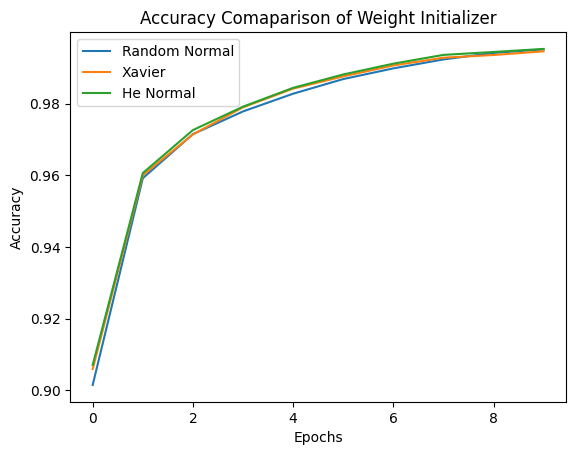

In [6]:
from re import VERBOSE
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.initializers import HeNormal,GlorotNormal,RandomNormal
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)


(X_train,y_train), (X_test,y_test) = mnist.load_data()

X_train = X_train/255.0
X_test = X_test/255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def create_model(initializer):
  model = Sequential([
      Dense(128, activation = 'relu', kernel_initializer = initializer,input_shape =(784,)),
      Dense(64, activation = 'relu', kernel_initializer = initializer),
      Dense(10, activation = 'softmax')
  ])
  return model


Initializer = {
    "Random Normal" : RandomNormal(),
    "Xavier" : GlorotNormal(),
    "He Normal" : HeNormal()
}

histories = {}

for name , init in Initializer.items():
  model = create_model(init)
  model.compile(
      optimizer = Adam(),
      loss = 'categorical_crossentropy',
      metrics = ['accuracy']
  )
  model_history = model.fit(
      X_train,y_train,
      epochs = 10,
      batch_size = 128,
      validation_data = (X_test,y_test),
      verbose = 0
  )
  histories[name] = model_history


for name , hist_data in histories.items():
  plt.plot(hist_data.history['accuracy'], label = name)

plt.title("Accuracy Comaparison of Weight Initializer")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

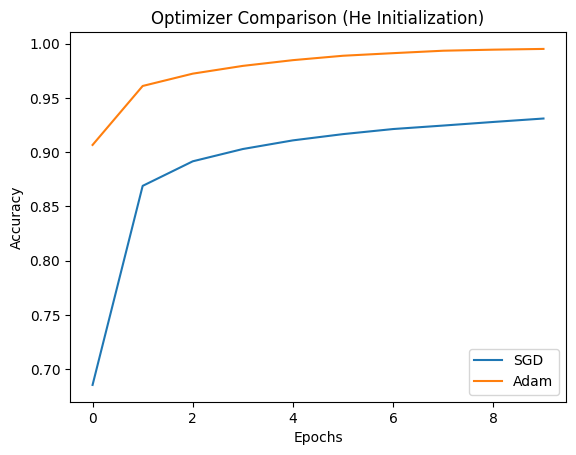

In [7]:
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "Adam": Adam()
}

optimizer_histories = {}

for name, opt in optimizers.items():
    model = create_model(HeNormal())
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_test, y_test),
        verbose=0
    )

    optimizer_histories[name] = history


for name, history in optimizer_histories.items():
    plt.plot(history.history['accuracy'], label=name)

plt.title("Optimizer Comparison (He Initialization)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


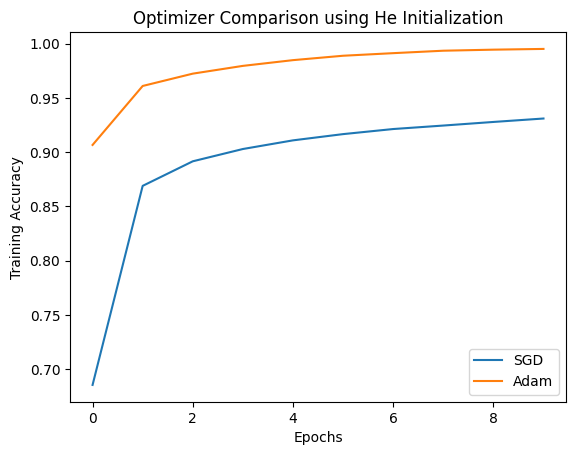

In [8]:
for name in optimizer_histories:
    plt.plot(optimizer_histories[name].history['accuracy'], label=name)

plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.title("Optimizer Comparison using He Initialization")
plt.legend()
plt.show()